# HarmoniDiff — demo verisiyle tekli test
Amac: pipe() cagrisinin gercekte hangi girdileri (prompt, metadata) kullandigini ve
hangi dosyalari urettigini anlamak, boylece kendi verimiz icin batch runner'i dogru yazabilelim.

## 1. Drive mount

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Yol tanimlari

In [4]:
ROOT = "/content/drive/MyDrive/SAR/SynDataGen"
HARMONIDIFF_DIR = f"{ROOT}/models/HarmoniDiff"

import os
print("HarmoniDiff dir var mi:", os.path.exists(HARMONIDIFF_DIR))
print("demo klasoru var mi:", os.path.exists(f"{HARMONIDIFF_DIR}/demo"))
print("demo icerigi:", os.listdir(f"{HARMONIDIFF_DIR}/demo") if os.path.exists(f"{HARMONIDIFF_DIR}/demo") else "YOK")

HarmoniDiff dir var mi: True
demo klasoru var mi: True
demo icerigi: ['background.tif', 'damaged.png', 'hospital_881_4_rgb.png', 'car_dealership_933_1_rgb.png', 'meta.json']


## 3. demo/meta.json icerigini incele

In [3]:
import json

meta_path = f"{HARMONIDIFF_DIR}/demo/meta.json"
with open(meta_path) as f:
    demo_meta = json.load(f)

print(json.dumps(demo_meta, indent=2, ensure_ascii=False))

{
  "country": "Brazil",
  "longitude": -55,
  "latitude": -10,
  "bg_gsd": 0.497808605433,
  "fg_gsd": 0.476020842791,
  "year": 2016,
  "month": 2,
  "day": 10,
  "cloud_cover": 0.06,
  "bg_prompt": "a satellite image of a hospital  in Brazil",
  "fg_prompt": "a satellite image of a car dealership  in Brazil",
  "bbox": [
    153,
    25,
    240,
    392
  ],
  "background": "background",
  "foreground": "damaged"
}


## 4. Bagimliliklari kur

In [3]:
!pip install --quiet -r "{HARMONIDIFF_DIR}/requirements.txt"

ERROR: Ignored the following versions that require a different python version: 1.21.2 Requires-Python >=3.7,<3.11; 1.21.3 Requires-Python >=3.7,<3.11; 1.21.4 Requires-Python >=3.7,<3.11; 1.21.5 Requires-Python >=3.7,<3.11; 1.21.6 Requires-Python >=3.7,<3.11
ERROR: Could not find a version that satisfies the requirement torch==2.5.1+cu121 (from versions: 2.2.0, 2.2.1, 2.2.2, 2.3.0, 2.3.1, 2.4.0, 2.4.1, 2.5.0, 2.5.1, 2.6.0, 2.7.0, 2.7.1, 2.8.0, 2.9.0, 2.9.1, 2.10.0, 2.11.0, 2.12.0, 2.12.1)
ERROR: No matching distribution found for torch==2.5.1+cu121


## 5. melike.py'yi demo verisiyle calistir

In [12]:
import subprocess

vis_path = f"{HARMONIDIFF_DIR}/visualization_test"

cmd = [
    "python", f"{HARMONIDIFF_DIR}/melike.py",
    "--data_path", f"{HARMONIDIFF_DIR}/demo",
    "--visualization_path", vis_path,
]
print("Calistirilacak komut:", " ".join(cmd))
print()

result = subprocess.run(cmd, cwd=HARMONIDIFF_DIR, capture_output=True, text=True)
print(result.stdout)
if result.returncode != 0:
    print("HATA:")
    print(result.stderr)

Calistirilacak komut: python /content/drive/MyDrive/SAR/SynDataGen/models/HarmoniDiff/melike.py --data_path /content/drive/MyDrive/SAR/SynDataGen/models/HarmoniDiff/demo --visualization_path /content/drive/MyDrive/SAR/SynDataGen/models/HarmoniDiff/visualization_test

fg boyutu: 147x281, yapıştırma konumu: (6,104)
301, 0.3708, 0.3319,  0.4120, 0.3685
351, 0.3735, 0.3348,  0.4112, 0.3746
401, 0.3689, 0.3280,  0.4046, 0.3741
451, 0.3663, 0.3240,  0.3951, 0.3799
501, 0.3395, 0.2976,  0.3695, 0.3513
551, 0.3282, 0.2871,  0.3609, 0.3367
601, 0.3991, 0.3538,  0.4319, 0.4116
651, 0.4366, 0.3937,  0.4493, 0.4669
Inference completed in 18.88 seconds.



## 6. Uretilen dosyalari listele (isim + boyut)

In [13]:
import os

files = sorted(os.listdir(vis_path))
for f in files:
    path = os.path.join(vis_path, f)
    size = os.path.getsize(path)
    print(f"{f}  ({size} bytes)")

301.png  (571726 bytes)
351.png  (572328 bytes)
401.png  (572449 bytes)
451.png  (572873 bytes)
501.png  (574633 bytes)
551.png  (574877 bytes)
601.png  (575204 bytes)
651.png  (575944 bytes)
bg.png  (429868 bytes)
edge_mask.png  (122 bytes)
init.png  (430497 bytes)
result.png  (575944 bytes)
shift_img.png  (572508 bytes)
used_bbox.json  (48 bytes)


## 7. Tum ciktilari gorsel olarak yan yana goster

In [14]:
import matplotlib.pyplot as plt
from PIL import Image

image_files = [f for f in files if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

fig, axes = plt.subplots(1, len(image_files), figsize=(4 * len(image_files), 4))
if len(image_files) == 1:
    axes = [axes]

for ax, f in zip(axes, image_files):
    img = Image.open(os.path.join(vis_path, f))
    ax.imshow(img)
    ax.set_title(f, fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

## 8. (varsa) json/diger dosyalarin icerigini yazdir

In [15]:
other_files = [f for f in files if not f.lower().endswith(('.png', '.jpg', '.jpeg'))]
for f in other_files:
    path = os.path.join(vis_path, f)
    print(f"--- {f} ---")
    try:
        with open(path) as fh:
            print(fh.read())
    except Exception as e:
        print(f"(okunamadi: {e})")
    print()

--- used_bbox.json ---
{
  "x": 6,
  "y": 104,
  "w": 147,
  "h": 281
}



In [7]:
import subprocess

cmd = [
    "python", f"{ROOT}/scripts/enrich_meta.py",
    "--synthetic_dir", f"{ROOT}/outputs/synthetic_pairs",
]
result = subprocess.run(cmd, capture_output=True, text=True)
print(result.stdout)
if result.returncode != 0:
    print("HATA:", result.stderr)

Guncellenen meta.json: 560
meta.json bulunamayan/atlanan klasor: 0



In [9]:
import subprocess

HARMONIDIFF_DIR = f"{ROOT}/models/HarmoniDiff"

cmd = [
    "python", "run_harmonidiff_single.py",
    "--synthetic_dir", f"{ROOT}/outputs/synthetic_pairs",
    "--out_dir", f"{ROOT}/outputs/harmonized",
    "--instances",
    "noto-earthquake_00000051_inst0001"
]

result = subprocess.run(cmd, cwd=HARMONIDIFF_DIR, capture_output=True, text=True)
print(result.stdout)
if result.returncode != 0:
    print("HATA:", result.stderr)

Model yukleniyor (BiliSakura/DiffusionSat-Single-512, device=cuda)...
Model hazir.
OK: noto-earthquake_00000051_inst0001 -> /content/drive/MyDrive/SAR/SynDataGen/outputs/harmonized/noto-earthquake_00000051_inst0001/result.png



Fark istatistigi: max=616.0, ortalama=0.12, degisen piksel orani (>10 fark)=%0.05


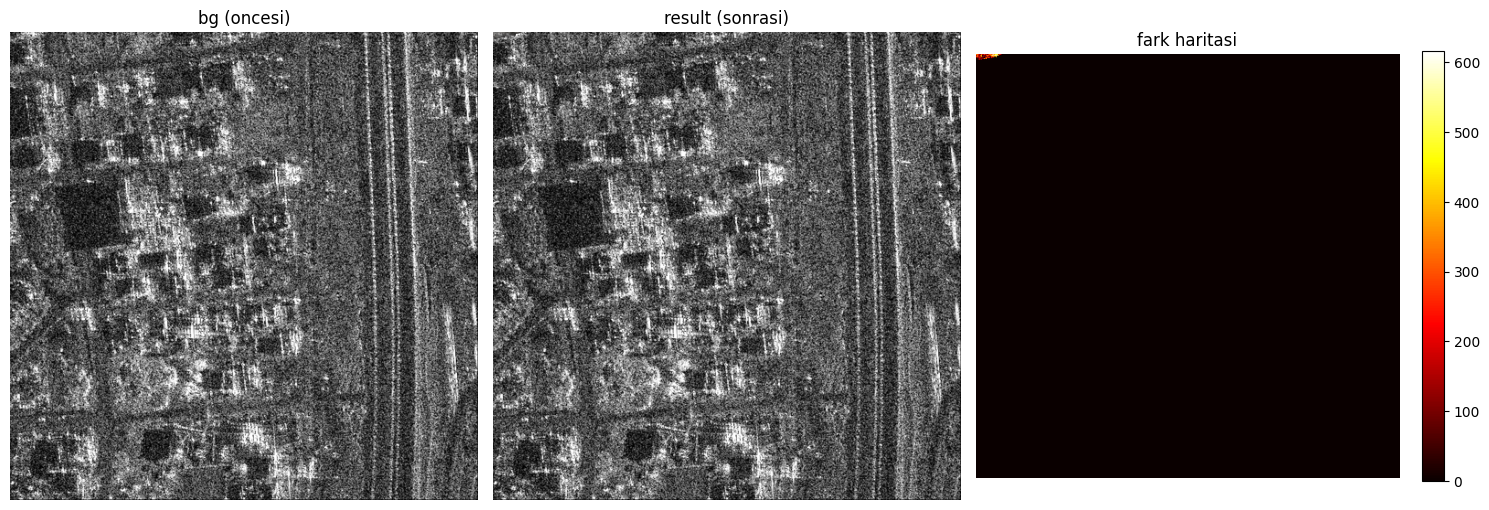

In [10]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

def compare_images(path1, path2, label1="bg (oncesi)", label2="result (sonrasi)"):
    img1 = np.array(Image.open(path1).convert("RGB")).astype(float)
    img2 = np.array(Image.open(path2).convert("RGB")).astype(float)

    if img1.shape != img2.shape:
        img2 = np.array(Image.open(path2).convert("RGB").resize(img1.shape[1::-1])).astype(float)

    diff = np.abs(img1 - img2).sum(axis=-1)
    print(f"Fark istatistigi: max={diff.max():.1f}, ortalama={diff.mean():.2f}, "
          f"degisen piksel orani (>10 fark)=%{100*(diff>10).mean():.2f}")

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img1.astype(np.uint8)); axes[0].set_title(label1); axes[0].axis('off')
    axes[1].imshow(img2.astype(np.uint8)); axes[1].set_title(label2); axes[1].axis('off')
    im = axes[2].imshow(diff, cmap='hot'); axes[2].set_title("fark haritasi"); axes[2].axis('off')
    plt.colorbar(im, ax=axes[2], fraction=0.046)
    plt.tight_layout()
    plt.show()

inst_dir_in = f"{ROOT}/outputs/synthetic_pairs/turkey-earthquake_00000933_inst0001"
inst_dir_out = f"{ROOT}/outputs/harmonized/turkey-earthquake_00000933_inst0001"

compare_images(f"{inst_dir_in}/bg.png", f"{inst_dir_out}/result.png")

Fark istatistigi: max=656.0, ortalama=0.89, degisen piksel orani (>10 fark)=%0.47


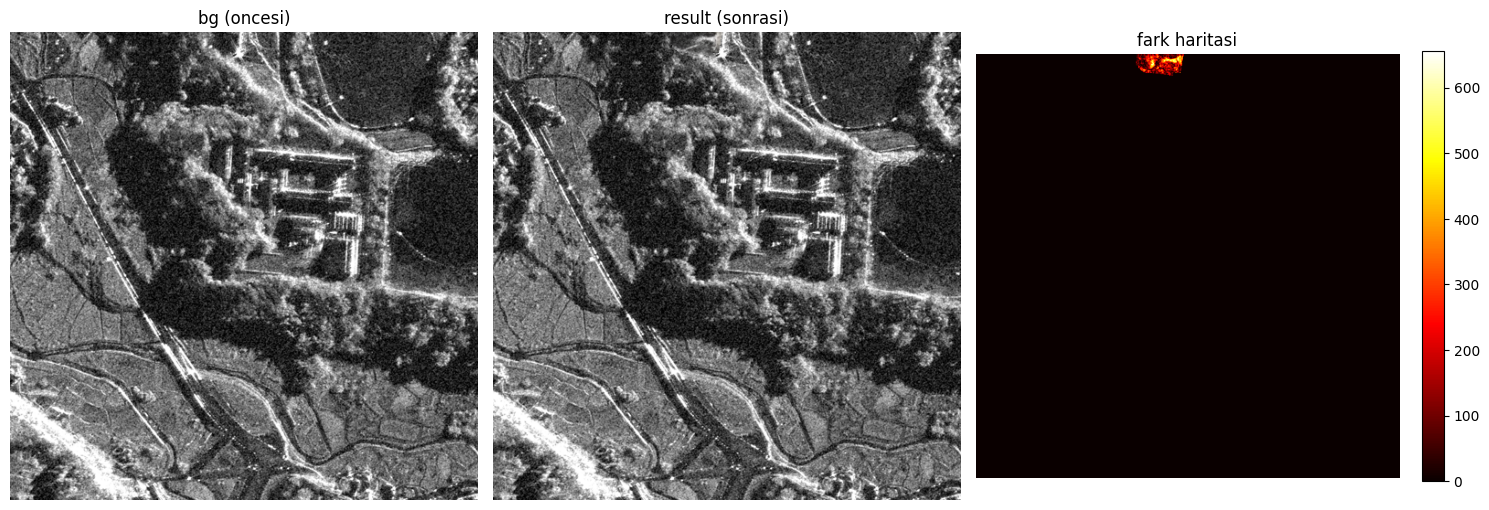

In [5]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

def compare_images(path1, path2, label1="bg (oncesi)", label2="result (sonrasi)"):
    img1 = np.array(Image.open(path1).convert("RGB")).astype(float)
    img2 = np.array(Image.open(path2).convert("RGB")).astype(float)

    if img1.shape != img2.shape:
        img2 = np.array(Image.open(path2).convert("RGB").resize(img1.shape[1::-1])).astype(float)

    diff = np.abs(img1 - img2).sum(axis=-1)
    print(f"Fark istatistigi: max={diff.max():.1f}, ortalama={diff.mean():.2f}, "
          f"degisen piksel orani (>10 fark)=%{100*(diff>10).mean():.2f}")

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img1.astype(np.uint8)); axes[0].set_title(label1); axes[0].axis('off')
    axes[1].imshow(img2.astype(np.uint8)); axes[1].set_title(label2); axes[1].axis('off')
    im = axes[2].imshow(diff, cmap='hot'); axes[2].set_title("fark haritasi"); axes[2].axis('off')
    plt.colorbar(im, ax=axes[2], fraction=0.046)
    plt.tight_layout()
    plt.show()

inst_dir_in = f"{ROOT}/outputs/synthetic_pairs/noto-earthquake_00000051_inst0001"
inst_dir_out = f"{ROOT}/outputs/harmonized/noto-earthquake_00000051_inst0001"

compare_images(f"{inst_dir_in}/bg.png", f"{inst_dir_out}/result.png")

Fark istatistigi: max=455.0, ortalama=0.04, degisen piksel orani (>10 fark)=%0.03


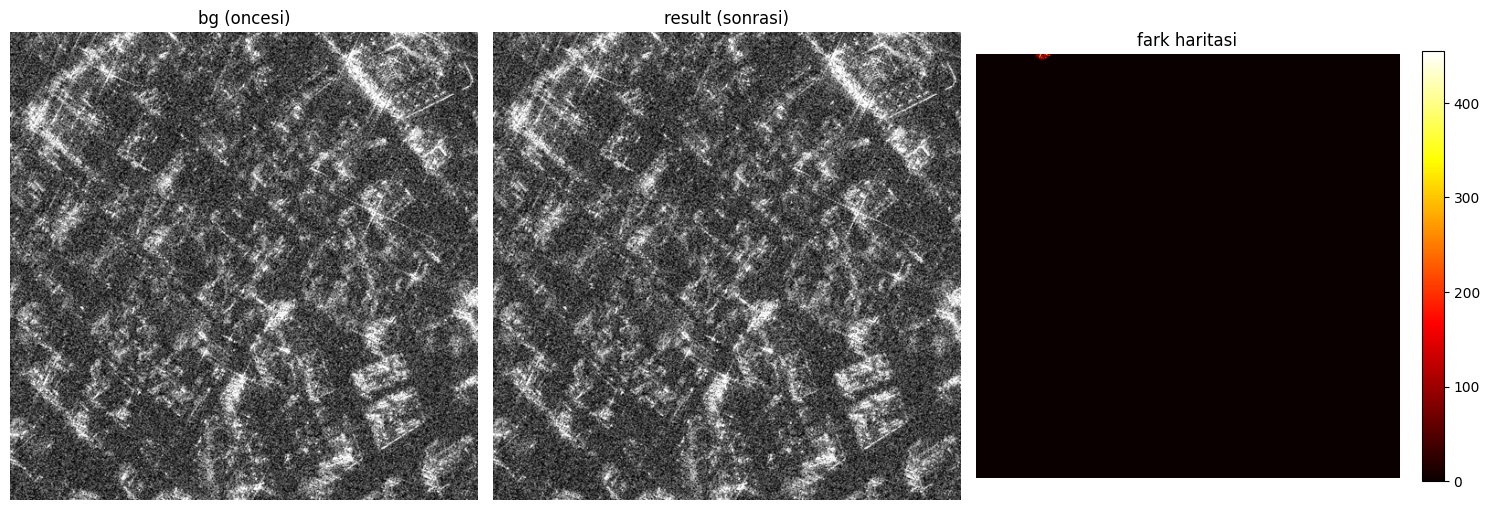

In [6]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

def compare_images(path1, path2, label1="bg (oncesi)", label2="result (sonrasi)"):
    img1 = np.array(Image.open(path1).convert("RGB")).astype(float)
    img2 = np.array(Image.open(path2).convert("RGB")).astype(float)

    if img1.shape != img2.shape:
        img2 = np.array(Image.open(path2).convert("RGB").resize(img1.shape[1::-1])).astype(float)

    diff = np.abs(img1 - img2).sum(axis=-1)
    print(f"Fark istatistigi: max={diff.max():.1f}, ortalama={diff.mean():.2f}, "
          f"degisen piksel orani (>10 fark)=%{100*(diff>10).mean():.2f}")

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img1.astype(np.uint8)); axes[0].set_title(label1); axes[0].axis('off')
    axes[1].imshow(img2.astype(np.uint8)); axes[1].set_title(label2); axes[1].axis('off')
    im = axes[2].imshow(diff, cmap='hot'); axes[2].set_title("fark haritasi"); axes[2].axis('off')
    plt.colorbar(im, ax=axes[2], fraction=0.046)
    plt.tight_layout()
    plt.show()

inst_dir_in = f"{ROOT}/outputs/synthetic_pairs/turkey-earthquake_00000778_inst0002"
inst_dir_out = f"{ROOT}/outputs/harmonized/turkey-earthquake_00000778_inst0002"

compare_images(f"{inst_dir_in}/bg.png", f"{inst_dir_out}/result.png")